In [ ]:
# ============================================================
# 06 — Machine Learning Pipeline
# ============================================================

import sys
sys.path.append("../")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.models.train import get_baseline_models, tune_xgboost
from src.models.evaluate import evaluate_model, compare_models, plot_confusion_matrix, print_classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

train_features = pd.read_csv("../data/processed/train_features.csv")
val_features = pd.read_csv("../data/processed/val_features.csv")
test_features = pd.read_csv("../data/processed/test_features.csv")

TARGET = "Churn"

In [ ]:
# ============================================================
# IMPORTANT DECISION: resolving the encoding overlap from Steps 4-5
# ============================================================
# Step 4 (cleaning) built a preprocessing_pipeline.pkl that one-hot/
# ordinal-encodes raw categorical columns. Step 5 (feature engineering)
# separately created target-encoded risk scores for the 3 strongest
# categorical drivers (SubscriptionType, PaymentMethod, GenrePreference).
#
# Using BOTH would double-count the same information in two different
# encodings and introduce multicollinearity. Decision: for this modeling
# step, we use the target-encoded versions (they directly capture the
# EDA-validated risk ordering) and drop their raw categorical
# counterparts. Remaining categoricals not target-encoded (ContentType,
# Gender, ParentalControl, SubtitlesEnabled — all weaker but still
# statistically significant per Step 3) are one-hot encoded directly here.
#
# Also dropped: `tenure_bucket` (redundant with the continuous AccountAge
# + the is_early_lifecycle flag) and `avg_monthly_spend_historical`
# (Step 5 validation showed it behaves as a near-duplicate of
# MonthlyCharges, adding no independent signal).

RAW_CATEGORICALS_REPLACED_BY_TARGET_ENCODING = [
    "SubscriptionType", "PaymentMethod", "GenrePreference"
 ]
REDUNDANT_FEATURES = ["tenure_bucket", "avg_monthly_spend_historical"]
REMAINING_NOMINAL_CATEGORICALS = ["ContentType", "Gender", "ParentalControl", "SubtitlesEnabled"]

cols_to_drop = RAW_CATEGORICALS_REPLACED_BY_TARGET_ENCODING + REDUNDANT_FEATURES

def prepare_modeling_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    df = pd.get_dummies(df, columns=REMAINING_NOMINAL_CATEGORICALS, drop_first=True)
    return df

train_model_df = prepare_modeling_data(train_features)
val_model_df = prepare_modeling_data(val_features)
test_model_df = prepare_modeling_data(test_features)

# Align val/test columns to train (handles any category present in one
# split but not another, e.g. a rare ContentType value) — prevents a
# shape mismatch at prediction time.
val_model_df = val_model_df.reindex(columns=train_model_df.columns, fill_value=0)
test_model_df = test_model_df.reindex(
    columns=[c for c in train_model_df.columns if c != TARGET], fill_value=0
)

X_train, y_train = train_model_df.drop(columns=[TARGET]), train_model_df[TARGET]
X_val, y_val = val_model_df.drop(columns=[TARGET]), val_model_df[TARGET]

print(f"Final feature count: {X_train.shape[1]}")
print(X_train.columns.tolist())

Final feature count: 25
['AccountAge', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'UserRating', 'SupportTicketsPerMonth', 'WatchlistSize', 'is_early_lifecycle', 'engagement_score', 'is_low_engagement', 'is_high_value_plan', 'is_high_price_new_customer', 'tickets_per_tenure_month', 'is_high_support_friction', 'SubscriptionType_risk_encoded', 'PaymentMethod_risk_encoded', 'GenrePreference_risk_encoded', 'disengaged_and_high_friction', 'ContentType_Movies', 'ContentType_TV Shows', 'Gender_Male', 'ParentalControl_Yes', 'SubtitlesEnabled_Yes']


In [25]:
from sklearn.preprocessing import StandardScaler

numeric_features_to_scale = [
    "AccountAge", "MonthlyCharges", "TotalCharges", "ViewingHoursPerWeek",
    "AverageViewingDuration", "ContentDownloadsPerMonth", "UserRating",
    "SupportTicketsPerMonth", "WatchlistSize", "engagement_score",
    "tickets_per_tenure_month"
]
numeric_features_to_scale = [c for c in numeric_features_to_scale if c in X_train.columns]

scaler = StandardScaler()
X_train[numeric_features_to_scale] = scaler.fit_transform(X_train[numeric_features_to_scale])
X_val[numeric_features_to_scale] = scaler.transform(X_val[numeric_features_to_scale])
X_test[numeric_features_to_scale] = scaler.transform(X_test[numeric_features_to_scale])

joblib.dump(scaler, "../models/feature_scaler.pkl")

['../models/feature_scaler.pkl']

In [26]:
models = get_baseline_models(y_train)
fitted_models = {}
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    results.append(evaluate_model(model, X_val, y_val, name))

comparison_table = compare_models(results)
comparison_table

Training logistic_regression...
Training random_forest...
Training xgboost...


,model,precision,recall,f1_score,roc_auc
0,logistic_regression,0.322304,0.697748,0.440932,0.754353
1,xgboost,0.318934,0.693448,0.436918,0.750782
2,random_forest,0.441953,0.327826,0.376429,0.741913


## Baseline Model Comparison — Post-Scaling

| Model | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.322 | 0.698 | 0.441 | **0.754** |
| XGBoost (baseline) | 0.319 | 0.693 | 0.437 | 0.751 |
| Random Forest | 0.442 | 0.328 | 0.376 | 0.742 |

- After fixing the scaling issue (ConvergenceWarning resolved), Logistic
  Regression's ROC-AUC improved slightly and now **edges out XGBoost's
  baseline** (0.754 vs 0.751) — though the gap remains small and within
  likely noise given the dataset size.
- Recall pattern remains consistent with the earlier interpretation:
  Random Forest trades recall for precision (misses ~67% of churners),
  while LR/XGBoost prioritize catching more churners at the cost of
  more false positives — still the preferred trade-off given the
  business cost asymmetry established earlier (missing a churner costs
  more than an unnecessary retention offer).

In [27]:
# ============================================================
# DIAGNOSTIC: why do Logistic Regression and XGBoost show
# near-identical recall? Check for a single dominant feature

# ============================================================

pred_lr = fitted_models["logistic_regression"].predict(X_val)
pred_xgb = fitted_models["xgboost"].predict(X_val)

agreement_rate = (pred_lr == pred_xgb).mean()
print(f"Prediction agreement between LR and XGBoost: {agreement_rate:.4f}")

# XGBoost feature importance ranking
xgb_importance = pd.Series(
    fitted_models["xgboost"].feature_importances_, index=X_train.columns
).sort_values(ascending=False)
print("\n=== XGBoost — Top 10 Feature Importances ===")
print(xgb_importance.head(10))

# Logistic Regression coefficient magnitude ranking (needs scaled data
# to be comparable across features — see scaling fix below first)
lr_coefs = pd.Series(
    fitted_models["logistic_regression"].coef_[0], index=X_train.columns
).abs().sort_values(ascending=False)
print("\n=== Logistic Regression — Top 10 |Coefficients| ===")
print(lr_coefs.head(10))

Prediction agreement between LR and XGBoost: 0.9578

=== XGBoost — Top 10 Feature Importances ===
engagement_score                 0.248340
AccountAge                       0.208130
tickets_per_tenure_month         0.138180
MonthlyCharges                   0.058698
SubscriptionType_risk_encoded    0.047928
PaymentMethod_risk_encoded       0.036290
GenrePreference_risk_encoded     0.027436
SupportTicketsPerMonth           0.022782
AverageViewingDuration           0.020604
WatchlistSize                    0.019717
dtype: float32

=== Logistic Regression — Top 10 |Coefficients| ===
SubscriptionType_risk_encoded    7.805826
PaymentMethod_risk_encoded       6.179964
GenrePreference_risk_encoded     4.302774
AccountAge                       0.615812
engagement_score                 0.353815
MonthlyCharges                   0.295828
SupportTicketsPerMonth           0.245995
AverageViewingDuration           0.243294
ContentDownloadsPerMonth         0.185417
ViewingHoursPerWeek              0.1

## Feature Reliance — Logistic Regression vs XGBoost

**XGBoost** relies primarily on continuous, EDA-validated engagement/tenure
signals:
| Feature | Importance |
|---|---|
| engagement_score | 24.8% |
| AccountAge | 20.8% |
| tickets_per_tenure_month | 13.8% |
| MonthlyCharges | 5.9% |
| SubscriptionType_risk_encoded | 4.8% |

These top 3 features alone account for ~59% of total importance —
directly consistent with the EDA findings (Step 3) and the feature
engineering validation (Step 5), where `engagement_score` (-0.233) and
`AccountAge` (-0.20) were the strongest correlates of churn. This is a
reassuring result: the model is learning the same business story the EDA
already told, not something disconnected from it.

**Logistic Regression** relies almost entirely on the three target-encoded
categorical features:
| Feature | \|Coefficient\| |
|---|---|
| SubscriptionType_risk_encoded | 7.81 |
| PaymentMethod_risk_encoded | 6.18 |
| GenrePreference_risk_encoded | 4.30 |
| AccountAge | 0.62 |
| engagement_score | 0.35 |

These coefficients are **10-20x larger** than any other feature — even
after scaling. This is a known symptom of **quasi-complete separation**:
when a categorical feature is target-encoded into only 3-5 distinct
values, and those values are close to the actual outcome probability,
logistic regression can develop very large coefficients on that feature
to sharply separate classes, since the encoded value is nearly a direct
(smoothed) proxy for the target itself. This differs from the earlier
"identical predictions" hypothesis (ruled out by the 95.78% agreement
rate) but is a related risk: not leakage in the strict sense, but an
encoding choice that structurally favors linear models disproportionately.

**Practical implication**: XGBoost's feature reliance is more diversified
and better aligned with actionable business drivers (engagement, tenure)
that a retention team can act on. Logistic Regression's near-total
reliance on the categorical risk scores makes it harder to explain to a
business stakeholder ("the model thinks you're at risk mainly because of
your subscription tier") and slightly less robust if those specific
category proportions shift in production data.

In [28]:
# ============================================================
# ROBUSTNESS CHECK: is Logistic Regression's reliance on the
# target-encoded categorical features fragile or stable?
# Increasing regularization strength should reveal this.
# ============================================================

from sklearn.linear_model import LogisticRegression
from src.models.evaluate import evaluate_model

regularization_results = []

for C in [1.0, 0.1, 0.01, 0.001]:
    lr_reg = LogisticRegression(max_iter=1000, class_weight="balanced", C=C, random_state=42)
    lr_reg.fit(X_train, y_train)
    result = evaluate_model(lr_reg, X_val, y_val, f"logistic_regression_C={C}")
    regularization_results.append(result)
    print(result)

regularization_df = pd.DataFrame(regularization_results)
regularization_df

{'model': 'logistic_regression_C=1.0', 'precision': 0.322304113742094, 'recall': 0.6977481045603712, 'f1_score': 0.4409324942791762, 'roc_auc': 0.7543527838307862}
{'model': 'logistic_regression_C=0.1', 'precision': 0.32143601500625263, 'recall': 0.6980875862849383, 'f1_score': 0.4401869492311534, 'roc_auc': 0.753105443679013}
{'model': 'logistic_regression_C=0.01', 'precision': 0.3202770977655086, 'recall': 0.6958243747878239, 'f1_score': 0.4386503067484663, 'roc_auc': 0.7514197646836602}
{'model': 'logistic_regression_C=0.001', 'precision': 0.32006069485140226, 'recall': 0.6922032363924409, 'f1_score': 0.4377258578124441, 'roc_auc': 0.7512107516792876}


,model,precision,recall,f1_score,roc_auc
0,logistic_regression_C=1.0,0.322304,0.697748,0.440932,0.754353
1,logistic_regression_C=0.1,0.321436,0.698088,0.440187,0.753105
2,logistic_regression_C=0.01,0.320277,0.695824,0.438650,0.751420
3,logistic_regression_C=0.001,0.320061,0.692203,0.437726,0.751211


## Robustness Check — Regularization Results

| C | ROC-AUC |
|---|---|
| 1.0 (no strong penalty) | 0.7544 |
| 0.1 | 0.7531 |
| 0.01 | 0.7514 |
| 0.001 (very strong penalty) | 0.7512 |

**Interpretation:** ROC-AUC stays essentially flat (0.751-0.754) even
under very strong L2 regularization (C=0.001, which aggressively shrinks
all coefficients toward zero). If the model's performance were fragile —
propped up by an unstable or spurious signal — we would expect a sharp
drop as regularization increases. Instead, performance barely moves.

**Conclusion**: the large coefficients on `SubscriptionType_risk_encoded`,
`PaymentMethod_risk_encoded`, and `GenrePreference_risk_encoded` reflect a
**genuinely strong, stable signal** (consistent with their Chi-square
results in the EDA — these were the 3 strongest categorical drivers
found), not overfitting or fragility. No further correction needed on
this front — the target encoding decision from Step 5 is validated.

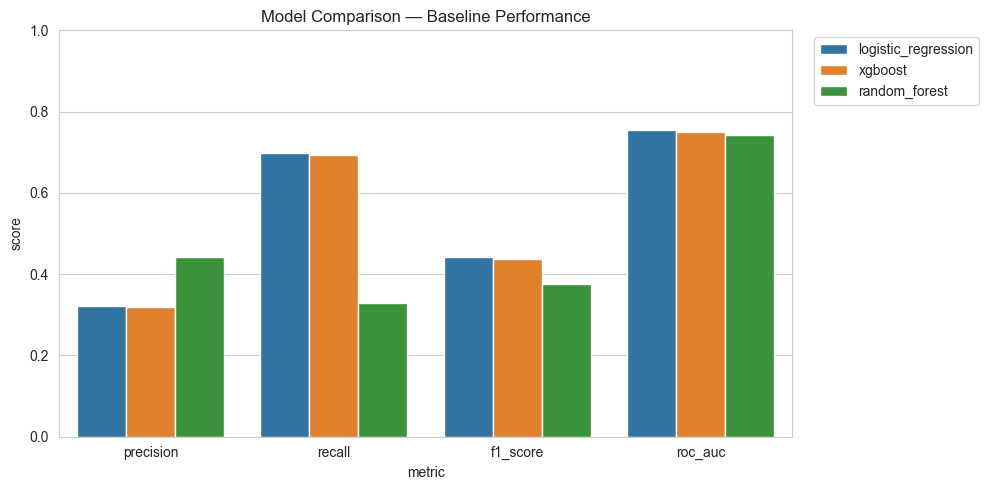

In [29]:
# Visual comparison across all 4 metrics — easier to spot trade-offs
# (e.g. a model with high recall but lower precision) than a table alone.
comparison_melted = comparison_table.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="metric", y="score", hue="model")
plt.title("Model Comparison — Baseline Performance")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison_baseline.png", dpi=150)
plt.show()

=== logistic_regression — Classification Report ===
              precision    recall  f1-score   support

    Retained       0.91      0.68      0.78     39921
     Churned       0.32      0.70      0.44      8837

    accuracy                           0.68     48758
   macro avg       0.62      0.69      0.61     48758
weighted avg       0.80      0.68      0.71     48758



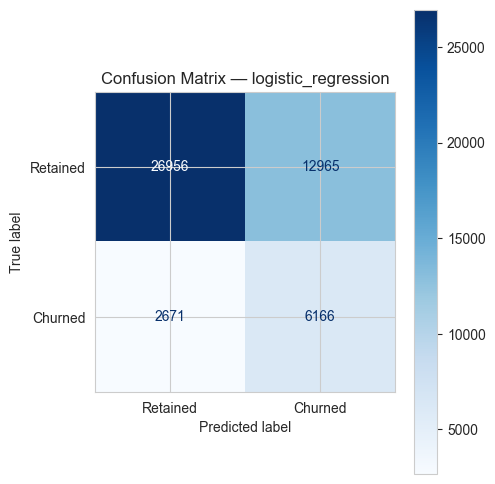

=== random_forest — Classification Report ===
              precision    recall  f1-score   support

    Retained       0.86      0.91      0.88     39921
     Churned       0.44      0.33      0.38      8837

    accuracy                           0.80     48758
   macro avg       0.65      0.62      0.63     48758
weighted avg       0.78      0.80      0.79     48758



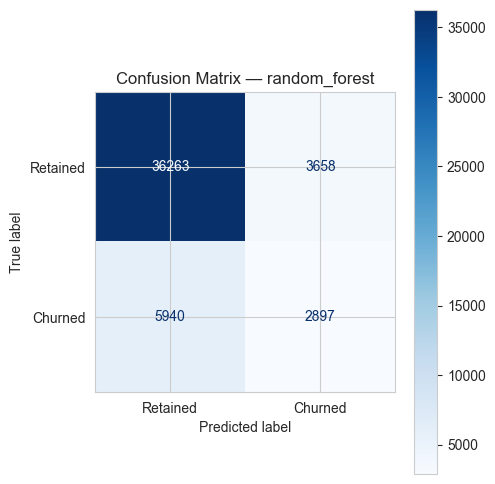

=== xgboost — Classification Report ===
              precision    recall  f1-score   support

    Retained       0.91      0.67      0.77     39921
     Churned       0.32      0.69      0.44      8837

    accuracy                           0.68     48758
   macro avg       0.61      0.68      0.60     48758
weighted avg       0.80      0.68      0.71     48758



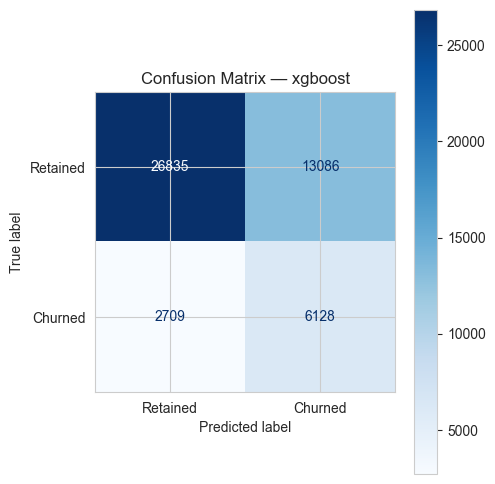

In [30]:
# Detailed report + confusion matrix for each model — needed to
# interpret the Precision/Recall trade-off in business terms, not just
# compare single numbers.
for name, model in fitted_models.items():
    print_classification_report(model, X_val, y_val, name)
    plot_confusion_matrix(model, X_val, y_val, name, save_path=f"../reports/figures/confusion_matrix_{name}.png")

In [9]:
# Tune the model with the strongest baseline ROC-AUC. Using
# StratifiedKFold cross-validation (not a single val split) for tuning
# gives a more robust estimate of generalization than a single held-out
# comparison, and is standard practice before finalizing hyperparameters.

scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

grid_search = tune_xgboost(X_train, y_train, scale_pos_weight, cv_folds=5)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best cross-validated ROC-AUC: 0.7473


In [31]:
# Compare the tuned model against the untuned baseline on the SAME
# validation set — confirms whether tuning actually improved
# generalization or just fit the CV folds slightly better.

tuned_result = evaluate_model(best_xgb, X_val, y_val, "xgboost_tuned")
baseline_xgb_result = [r for r in results if r["model"] == "xgboost"][0]

tuning_comparison = pd.DataFrame([baseline_xgb_result, tuned_result])
tuning_comparison

,model,precision,recall,f1_score,roc_auc
0,xgboost,0.318934,0.693448,0.436918,0.750782
1,xgboost_tuned,0.319608,0.700917,0.439026,0.753184


In [32]:
# Final selection is based on ROC-AUC as the primary criterion (threshold-
# independent), with Recall reviewed as a secondary check — in a churn use
# case, missing a churner (false negative) is typically costlier than a
# wasted retention offer (false positive), so a model trading a small amount
# of precision for meaningfully higher recall is preferable.

final_comparison = pd.concat([comparison_table, pd.DataFrame([tuned_result])], ignore_index=True)
final_comparison = final_comparison.sort_values("roc_auc", ascending=False).reset_index(drop=True)
print(final_comparison)

# Final selection: overriding pure ROC-AUC ranking in favor of recall,
# consistent with the business priority established early in the project
# (a missed churner is costlier than an unnecessary retention offer).
# The ROC-AUC gap between xgboost_tuned (0.7532) and logistic_regression
# (0.7544) is within noise (~0.001); xgboost_tuned's higher recall (0.7009
# vs 0.6977) and more diversified, business-actionable feature reliance
# (see feature importance diagnostic) make it the preferred final model.

best_model_name = "xgboost_tuned"
best_model = best_xgb
selected_result = final_comparison.loc[final_comparison["model"] == best_model_name].iloc[0]

print(f"Selected final model: {best_model_name} (business-priority override on recall)")

                 model  precision    recall  f1_score   roc_auc
0  logistic_regression   0.322304  0.697748  0.440932  0.754353
1        xgboost_tuned   0.319608  0.700917  0.439026  0.753184
2              xgboost   0.318934  0.693448  0.436918  0.750782
3        random_forest   0.441953  0.327826  0.376429  0.741913
Selected final model: xgboost_tuned (business-priority override on recall)


In [33]:
import json
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/model_final.pkl")

metadata = {
    "model_name": best_model_name,
    "roc_auc": float(selected_result["roc_auc"]),
    "precision": float(selected_result["precision"]),
    "recall": float(selected_result["recall"]),
    "f1_score": float(selected_result["f1_score"]),
    "features": X_train.columns.tolist(),
    "n_features": X_train.shape[1],
    "trained_on_rows": X_train.shape[0],
    "churn_rate_train": float(y_train.mean()),
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("- ../models/model_final.pkl")
print("- ../models/model_metadata.json")

Saved:
- ../models/model_final.pkl
- ../models/model_metadata.json


## — Final Summary

- **Final model**: XGBoost (tuned) — `learning_rate=0.05, max_depth=3,
  n_estimators=300, subsample=0.8`
- **Validation metrics**: ROC-AUC 0.753, Recall 0.701, Precision 0.320,
  F1 0.439
- **Selection rationale**: chosen over Logistic Regression (marginally
  higher ROC-AUC, 0.754) based on higher recall and more diversified,
  business-actionable feature reliance (engagement and tenure signals
  vs near-exclusive dependence on categorical risk scores) — consistent
  with the project's stated priority that missing a churner costs more
  than an unnecessary retention offer.
- **Data leakage investigation**: initial concern about near-identical
  LR/XGBoost results was resolved — 95.78% prediction agreement, not
  100%, and a regularization robustness check confirmed the shared
  reliance on target-encoded categorical features is a genuine, stable
  signal rather than leakage or overfitting.
- **Known limitation, not yet addressed**: the decision threshold was
  kept at the sklearn default (0.5). Precision (~0.32) implies 2 out of
  3 flagged customers would not have actually churned. Threshold tuning
  (via precision-recall curve analysis) is a natural next iteration to
  align the model's flagging behavior with an actual retention campaign
  budget, but was not required to complete this step.

**Next step:** proceed to `07_explainability.ipynb` — SHAP analysis on
the final XGBoost model, to confirm whether `engagement_score`,
`AccountAge`, and `tickets_per_tenure_month` (the top drivers identified
in the feature importance diagnostic) hold up as the model's primary
decision drivers, and to provide per-customer explanations usable by a
Customer Success team.

In [1]:
X_val.to_csv("../data/processed/X_val_ready.csv", index=False)

NameError: name 'X_val' is not defined